## Import Dependencies

In [4]:
!python -m pip install -r ../requirements.txt


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/telco-churn.csv')

### 1. Xem các giá trị unique của `Contract`

In [6]:
unique_contract = df['Contract'].unique()
print(unique_contract)

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str


Có 3 giá trị là `Month-to-month`, `One year` và `Two year`

### 2. Tính các loại thuộc tính của từng loại `Contract`

#### 2.1 Tổng số `customer`

In [7]:
customers = df.groupby('Contract')['customerID'].count()
print(customers)

Contract
Month-to-month    3875
One year          1473
Two year          1695
Name: customerID, dtype: int64


#### 2.2 Số customer Churn

In [8]:
churned = df[df['Churn'] == 'Yes'].groupby('Contract')['customerID'].count()
print(churned)

Contract
Month-to-month    1655
One year           166
Two year            48
Name: customerID, dtype: int64


#### 2.3 Churn rate

In [9]:
ChurnRate = churned / customers
print(ChurnRate)

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: customerID, dtype: float64


#### 2.4 Gộp cả 3 lại

In [10]:
summary = pd.DataFrame({
    'Customers': customers,
    'Churned': churned,
    'ChurnRate': ChurnRate
})
summary

,Customers,Churned,ChurnRate
Contract,,,
Month-to-month,3875,1655,0.427097
One year,1473,166,0.112695
Two year,1695,48,0.028319


### 3. Sort theo ChurnRate giảm dần

In [11]:
summary = summary.sort_values(
    "ChurnRate",
    ascending=False
)
summary

,Customers,Churned,ChurnRate
Contract,,,
Month-to-month,3875,1655,0.427097
One year,1473,166,0.112695
Two year,1695,48,0.028319


Từ bảng trên có thể thấy nhóm khách hàng sử dụng hợp đồng `Month-to-month` có churn rate cao hơn đáng kể so với nhóm `One year` và `Two year`. Đồng thời, churn rate giảm khi thời hạn hợp đồng tăng. Điều này cho thấy Contract có mối liên hệ rõ ràng với Churn trong dataset. Tuy nhiên, chưa thể kết luận rằng hợp đồng dài trực tiếp làm giảm churn vì còn có thể tồn tại các yếu tố khác liên quan đến cả loại hợp đồng và hành vi churn. Ngoài ra, số lượng khách hàng giữa các loại hợp đồng không cân bằng, vì vậy nên ưu tiên so sánh churn rate thay vì số lượng churn tuyệt đối.

### Kiểm tra tenure

In [12]:
summary_tenure = (
    df.groupby('tenure')
      .agg(
          Customers = ("customerID", "count"),
          Churn = ("Churn", lambda x: (x == "Yes").sum()),
          ChurnRate = ("Churn", lambda x: (x == "Yes").mean())
      )
)
summary_tenure = summary_tenure.sort_values(
    "ChurnRate",
    ascending=True
)
summary_tenure

,Customers,Churn,ChurnRate
tenure,,,
0,11,0,0.000000
72,362,6,0.016575
71,170,6,0.035294
64,80,4,0.050000
63,72,4,0.055556
...,...,...,...
3,200,94,0.470000
4,176,83,0.471591
5,133,64,0.481203


In [13]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [14]:
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12 months', '13-24 months', '25-36 months', '37-48 months', '49-60 months', '61-72 months']

df['tenure_new'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)
df['tenure_new']

0        0-12 months
1       25-36 months
2        0-12 months
3       37-48 months
4        0-12 months
            ...     
7038    13-24 months
7039    61-72 months
7040     0-12 months
7041     0-12 months
7042    61-72 months
Name: tenure_new, Length: 7043, dtype: category
Categories (6, str): ['0-12 months' < '13-24 months' < '25-36 months' < '37-48 months' < '49-60 months' < '61-72 months']

In [15]:
summary_tenure_new = (
    df.groupby('tenure_new')
      .agg(
          Customers = ("customerID", "count"),
          Churn = ("Churn", lambda x: (x == "Yes").sum()),
          ChurnRate = ("Churn", lambda x: (x == "Yes").mean())
      )
)
summary_tenure_new = summary_tenure_new.sort_values(
    "ChurnRate",
    ascending=False
)
summary_tenure_new

,Customers,Churn,ChurnRate
tenure_new,,,
0-12 months,2186,1037,0.474382
13-24 months,1024,294,0.287109
25-36 months,832,180,0.216346
37-48 months,762,145,0.190289
49-60 months,832,120,0.144231
61-72 months,1407,93,0.066098


In [16]:
df.groupby("Churn")['tenure'].agg(["count", "mean", "median"])

,count,mean,median
Churn,,,
No,5174,37.569965,38.0
Yes,1869,17.979133,10.0


Từ bảng có thể thấy các nhóm khách hàng có tenure thấp có ChurnRate cao hơn, và ChurnRate nhìn chung giảm khi tenure tăng. Kết quả này cũng phù hợp với việc mean tenure của nhóm Churn = Yes thấp hơn nhóm Churn = No. Hai quan sát đều cho thấy tenure có mối liên hệ với churn: những khách hàng mới hoặc có thời gian gắn bó ngắn có xu hướng churn nhiều hơn trong dataset. Tuy nhiên, đây mới chỉ là mối liên hệ quan sát được; chưa thể kết luận tenure thấp trực tiếp gây ra churn vì còn có thể tồn tại những yếu tố khác liên quan đến cả tenure và churn.

### MonthlyCharges

In [17]:
df.groupby('Churn')['MonthlyCharges'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])

,count,mean,median,std,min,max
Churn,,,,,,
No,5174,61.265124,64.425,31.092648,18.25,118.75
Yes,1869,74.441332,79.650,24.666053,18.85,118.35


Người Churn có tỷ lệ MonthlyCharges cao hơn người không churn.

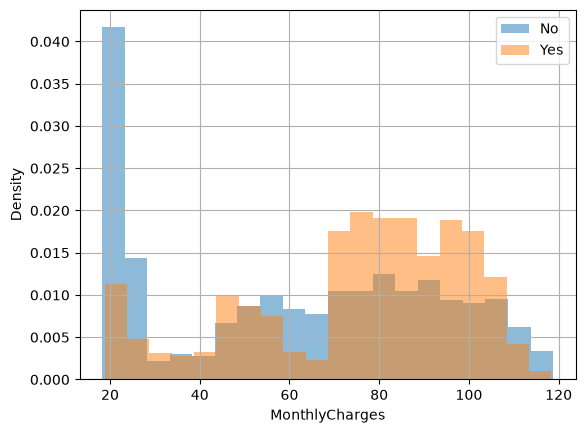

In [18]:
df[df['Churn'] == "No"]['MonthlyCharges'].hist(
    alpha=0.5,
    bins=20,
    density=True,
    label="No"
)

df[df['Churn'] == "Yes"]['MonthlyCharges'].hist(
    alpha=0.5,
    bins=20,
    density=True,
    label="Yes"
)
plt.xlabel("MonthlyCharges")
plt.ylabel("Density")
plt.legend()
plt.show()

Theo biểu đồ, có thể thấy số người có Churn là No thì MonthlyCharges thấp, còn những người Yes thì MonthlyCharges cao.

In [19]:
bins = [0, 20, 40, 60, 80, 100, 120]
labels = ['$0-20', '$20-40', '$40-60', '$60-80', '$80-100', '$100-120']

df['MonthlyCharges_group'] = pd.cut(df['MonthlyCharges'], bins = bins, labels=labels, include_lowest=True, right=False)

In [20]:
monthly_summary = (
    df.groupby(
        'MonthlyCharges_group',
        observed=True
    )
    .agg(
        Customers=("customerID", "count"),
        Churned=("Churn", lambda x: (x == "Yes").sum()),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean())
    )
)
monthly_summary

,Customers,Churned,ChurnRate
MonthlyCharges_group,,,
$0-20,613,55,0.089723
$20-40,1224,158,0.129085
$40-60,1070,276,0.257944
$60-80,1459,470,0.322138
$80-100,1769,653,0.369135
$100-120,908,257,0.283040


Số tiền từ trung bình đến cao có ChurnRate cao hơn rất nhiều so với những người có MonthlyCharges `$0-20`. Nhưng không thể kết luận rằng MonthlyCharges đồng nghĩa với việc là người tiêu dùng sẽ rời đi. MonthlyCharges cao có thể đến từ các dịch vụ mà người dùng đăng ký.

Nhóm khách hàng Churn = Yes có MonthlyCharges nhìn chung cao hơn nhóm Churn = No. Distribution của nhóm churn cũng có xu hướng tập trung ở các mức phí cao hơn. Khi chia MonthlyCharges thành các khoảng, các nhóm có mức phí trung bình đến cao có ChurnRate cao hơn đáng kể so với nhóm có MonthlyCharges khoảng $0–20. Điều này cho thấy MonthlyCharges có mối liên hệ với Churn trong dataset. Tuy nhiên, chưa thể kết luận mức phí cao trực tiếp khiến khách hàng rời dịch vụ, vì MonthlyCharges có thể phụ thuộc vào các dịch vụ mà khách hàng đăng ký và những dịch vụ đó cũng có thể liên quan đến Churn.

### InternetService

In [21]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [22]:
Internet_summary = (
    df.groupby('InternetService')
      .agg(
          Customer = ('customerID', 'count'),
          Churn = ("Churn", lambda x: (x == "Yes").sum()),
          ChurnRate = ("Churn", lambda x: (x == "Yes").mean()),
      )
)
Internet_summary

,Customer,Churn,ChurnRate
InternetService,,,
DSL,2421,459,0.189591
Fiber optic,3096,1297,0.418928
No,1526,113,0.074050


Những khách hàng có sử dụng dịch vụ InternetService thì sẽ có ChurnRate cao hơn những khách hàng không sử dụng. Đồng thời, khách hàng sử dụng cáp quang sẽ có ChurnRate cao hơn khách hàng sử dụng cáp đồng, đường dây điện thoại bình thường.

In [23]:
df.groupby('InternetService')['MonthlyCharges'].agg(
    ['count', 'mean', 'median', 'std']
)

,count,mean,median,std
InternetService,,,,
DSL,2421,58.102169,56.150,16.259522
Fiber optic,3096,91.500129,91.675,12.663039
No,1526,21.079194,20.150,2.164221


Dựa từ thông tin bảng ChurnRate và bảng MonthlyCharges, nhóm Fiber optic có ChurnRate cao nhất cũng đồng thời có MonthlyCharges cao nhất. Nhóm No tức là khách hàng không sử dụng dịch vụ lại là nhóm có ChurnRate và MonthlyCharges thấp nhất. Hai pattern này xảy ra đồng thời và cho thấy InternetService có liên hệ với cả MonthlyCharges và Churn. Nhưng chưa thể kết luận rằng InternetService là nguyên nhân, vì dù không sử dụng InternetService thì có thể khách hàng sử dụng các dịch vụ còn lại. MonthlyCharges cũng là giá tiền sau cùng khi sử dụng tất cả dịch vụ còn lại. Nhưng có thể biết rằng InternetSerive có mối liên hệ mạnh với MonthlyCharges; khách Fiber optic có mức phí hàng tháng cao hơn rõ rệt còn nhóm không dùng InternetService có mức phí thấp hơn.

In [27]:
df.groupby(
    ["InternetService", "Churn"]
)["MonthlyCharges"].agg(
    [
        "count",
        "mean",
        "median",
        "std"
    ]
)

count       mean  median        std
InternetService Churn                                     
DSL             No      1962  60.212105   59.75  16.109146
                Yes      459  49.083224   49.25  13.608829
Fiber optic     No      1799  93.932379   94.80  12.653712
                Yes     1297  88.126484   87.55  11.882834
No              No      1413  21.136058   20.15   2.201510
                Yes      113  20.368142   20.00   1.456851

Khi xét toàn bộ dataset, nhóm khách hàng churn có MonthlyCharges trung bình cao hơn nhóm không churn. Tuy nhiên, khi phân tích riêng trong từng loại InternetSerivem kết quả lại đảo chiều: ở cả DSL, Fiber optic và nhóm không sử dụng internet, khách hàng churn có MonthlyCharges trung bình thấp hơn khách hàng không churn. Điều này cho thấy mối liên hệ quan sát được giữa MonthlyCharges và Churn bị ảnh hưởng mạnh bởi InternetSerive. Nhóm churn có tỷ lệ khách Fiber optic cao hơn, trong khi Fiber optic vốn có MonthlyCharges cao hơn các loại dịch vụ khác. Vì vậy, không nên diễn giải MonthlyCharges một cách độc lập mà không xét đến InternetSerive.

In [28]:
pd.crosstab(
    df['Churn'],
    df['InternetService'],
    normalize="index"
)

InternetService,DSL,Fiber optic,No
Churn,,,
No,0.379204,0.347700,0.273096
Yes,0.245586,0.693954,0.060460


Phân bố InternetService giữa hai nhóm Churn không giống nhau. Trong nhóm Churn = Yes, khoảng 69% khách hàng sử dụng Fiber optic, trong khi tỷ lệ này chỉ khoảng 35% ở nhóm Churn = No. Ngược lại, nhóm không churn có tỷ lệ khách dùng DSL hoặc không sử dụng Internet cao hơn. Vì Fiber optic có MonthlyCharges cao hơn đáng kể so với các nhóm còn lại, tỷ trọng lớn của Fiber optic trong nhóm churn kéo MonthlyCharges trung bình của toàn nhóm này lên. Điều này giải thích tại sao khi xét toàn bộ dữ liệu, nhóm churn có MonthlyCharges trung bình cao hơn, dù khi giữ InternetService cố định thì MonthlyCharges của churner lại thấp hơn non-churner.

### PaymentMethod

In [29]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [33]:
Payment_summary = (
    df.groupby('PaymentMethod')
      .agg(
          Customers = ("customerID", "count"),
          Churned = ("Churn", lambda x: (x == "Yes").sum()),
          ChurnRate = ("Churn", lambda x: (x == "Yes").mean())
      )
)
Payment_summary = Payment_summary.sort_values("ChurnRate", ascending=False)
Payment_summary

,Customers,Churned,ChurnRate
PaymentMethod,,,
Electronic check,2365,1071,0.452854
Mailed check,1612,308,0.191067
Bank transfer (automatic),1544,258,0.167098
Credit card (automatic),1522,232,0.152431


Đánh giá nhanh có thể thấy Electronic check có ChurnRate khá cao. Credit card một cách tự động đang có ChurnRate thấp nhất. Chênh lệch ChurnRate giữa Electronic check so với Mailed check là khoảng 26.2%, với Bank transfer là khoảng 28,5%, và với Credit card là 30,1%. Nhưng chưa thể kết luận Electronic check trực tiếp gây churn. Có thể yếu tố tổ hợp các dịch vụ khác, việc kết luận một mình Electronic check gây churn là không đúng. Tuy nhiên, ta có thể thấy rằng PaymentMethod cũng có mối liên hệ về Churn.

In [34]:
pd.crosstab(
    df["PaymentMethod"],
    df["Contract"],
    normalize="index"
)

Contract,Month-to-month,One year,Two year
PaymentMethod,,,
Bank transfer (automatic),0.381477,0.253238,0.365285
Credit card (automatic),0.356767,0.261498,0.381735
Electronic check,0.782241,0.146723,0.071036
Mailed check,0.553970,0.209057,0.236973


Khách hàng sử dụng Electronic check tập trung mạnh ở nhóm Month-to-month, với khoảng 78.2%, trong khi chỉ khoảng 14.7% thuộc One-year và 7.1% thuộc Two-year. Mailed check cũng có tỷ lệ Month-to-month tương đối cao, khoảng 55.4%. Ngược lại, Bank transfer và Credit card có phân bố cân bằng hơn giữa các loại hợp đồng. Vì Month-to-month trước đó được quan sát có ChurnRate cao nhất, sự khác biệt về cơ cấu Contract có thể giải thích một phần việc Electronic check có ChurnRate cao. Do đó chưa nên diễn giải PaymentMethod độc lập khỏi Contract.

In [36]:
df.groupby(
    ['Contract', 'PaymentMethod']
)["Churn"].agg(
    Customer="count",
    ChurnRate=lambda x: (x == "Yes").mean()
)

Customer  ChurnRate
Contract       PaymentMethod                                 
Month-to-month Bank transfer (automatic)       589   0.341256
               Credit card (automatic)         543   0.327808
               Electronic check               1850   0.537297
               Mailed check                    893   0.315789
One year       Bank transfer (automatic)       391   0.097187
               Credit card (automatic)         398   0.103015
               Electronic check                347   0.184438
               Mailed check                    337   0.068249
Two year       Bank transfer (automatic)       564   0.033688
               Credit card (automatic)         581   0.022375
               Electronic check                168   0.077381
               Mailed check                    382   0.007853

Khi giữ Contract cố định, Electronic check vẫn có ChurnRate cao nhất trong cả ba loại hợp đồng: khoảng 53.7% đối với Month-to-month, 18.4% với One year và 7.7% với Two year. Điều này cho thấy ChurnRate cao của Electronic check không thể được giải thích hoàn toàn bởi việc nhóm này có nhiều khách Month-to-month, mặc dù Contract vẫn có ảnh hưởng lớn vì churn rate giảm mạnh khi thời hạn hợp đồng tăng. Đáng chú ý, Mailed check có ChurnRate tổng thể cao thứ hai, nhưng lại có ChurnRate thấp nhất trong từng loại Contract. Điều này cho thấy ChurnRate tổng thể của Mailed check bị ảnh hưởng bởi cơ cấu Contract, đặc biệt vì nhóm này chứa nhiều khách Month-to-month.